# Chapter 07 — Intelligence in the Wrong Direction

**Companion to *Applied AI*.**

This notebook accompanies Chapter 7. The chapter's reframe is that **evals are
experiments**. This notebook builds the smallest honest harness and then shows
what the standard industry comparison is actually capable of detecting.

## Question

You ran two models on twenty examples and one won fourteen to six.
**Can this evaluation tell them apart?**

## What this notebook establishes

- The chapter's two arithmetic results, reproduced exactly: a 14–6 split has a
  two-sided p of about 0.115 under a fair coin, and a 40/50 pass rate carries a
  standard error of about 0.057.
- Why one run is a draw and not a measurement: repeated draws from the same
  frozen task set produce a distribution, not a number.
- A **paired** comparison recovering a real difference that the same data,
  analysed unpaired, cannot see.
- A power curve: the number of items this eval would need before it could
  detect the effect you want to claim.

## What this notebook does **not** establish

- The "models" here are local Bernoulli samplers with known pass
  probabilities, **not language models**. They exist so that the true effect is
  known and the statistics can be checked against it.
- Nothing here validates a critic, measures agreement with humans, or
  reproduces the chapter's cited results (Miller; Zheng et al.; Gao et al.).
- A power calculation tells you what an eval can detect. It says nothing about
  whether the eval measures the thing you care about.

## Setup

In [1]:
import random
import statistics
from math import comb, sqrt

import matplotlib.pyplot as plt

SEED = 42

## 1. The twenty-example comparison

The chapter: *two equally good models split at least that lopsidedly about one
time in nine.*

In [2]:
def two_sided_p(n, wins):
    """Exact binomial test against a fair coin, two-sided by symmetry."""
    hi = sum(comb(n, k) for k in range(wins, n + 1))
    return 2 * hi / 2 ** n

n, wins = 20, 14
p = two_sided_p(n, wins)
print(f"head-to-head items      : {n}")
print(f"won by the new model    : {wins}")
print(f"two-sided p (fair coin) : {p:.3f}   (about 1 in {1/p:.0f})")
assert abs(p - 0.115) < 0.001
print()
print("assertion held: reproduces the chapter's figure")

head-to-head items      : 20
won by the new model    : 14
two-sided p (fair coin) : 0.115   (about 1 in 9)

assertion held: reproduces the chapter's figure


## A pass rate is an estimate, not a fact

In [3]:
rate, runs = 40 / 50, 50
se = sqrt(rate * (1 - rate) / runs)
lo, hi = rate - 1.96 * se, rate + 1.96 * se

print(f"observed pass rate : {rate:.2f}  ({int(rate*runs)}/{runs})")
print(f"standard error     : {se:.3f}")
print(f"95% interval       : {lo:.2f} to {hi:.2f}")
assert abs(se - 0.057) < 0.001
print()
print("assertion held: reproduces the chapter's ~6 points")
print()
print('The chapter\'s reading: "somewhere around 69% to 91%".')
print("Two models whose intervals overlap that much have not been told apart.")

observed pass rate : 0.80  (40/50)
standard error     : 0.057
95% interval       : 0.69 to 0.91

assertion held: reproduces the chapter's ~6 points

The chapter's reading: "somewhere around 69% to 91%".
Two models whose intervals overlap that much have not been told apart.


## 2. One run is a draw

A frozen task set of 40 items. Each model has a fixed per-item pass
probability, so the *true* difference is known. Run the eval once, the way most
comparisons are run.

In [4]:
N_TASKS = 40
TRUE_A, TRUE_B = 0.70, 0.76      # B is genuinely better, by 6 points

def draw(rng, p, n=N_TASKS):
    return [1 if rng.random() < p else 0 for _ in range(n)]

rng = random.Random(SEED)
a_once, b_once = draw(rng, TRUE_A), draw(rng, TRUE_B)
print(f"single run:  A = {sum(a_once)}/{N_TASKS}   B = {sum(b_once)}/{N_TASKS}"
      f"   -> B ahead by {sum(b_once)-sum(a_once)}")
print()
print(f"true difference, known by construction: {TRUE_B - TRUE_A:+.2f}")

single run:  A = 29/40   B = 33/40   -> B ahead by 4

true difference, known by construction: +0.06


Now run the same eval 400 times and look at what that single number was a
sample *of*.

In [5]:
REPEATS = 400
rng = random.Random(SEED + 1)
diffs = [sum(draw(rng, TRUE_B)) - sum(draw(rng, TRUE_A)) for _ in range(REPEATS)]

wrong_sign = sum(1 for d in diffs if d <= 0)
print(f"repeats                 : {REPEATS}")
print(f"mean observed difference: {statistics.fmean(diffs):+.2f} items")
print(f"range                   : {min(diffs):+d} to {max(diffs):+d} items")
print(f"runs where B did NOT win: {wrong_sign}  ({wrong_sign/REPEATS:.1%})")
print()
print("A truly better model loses this eval a substantial share of the time.")
print("That is what 'one run is a sample, not a measurement' costs you.")

repeats                 : 400
mean observed difference: +2.17 items
range                   : -8 to +13 items
runs where B did NOT win: 126  (31.5%)

A truly better model loses this eval a substantial share of the time.
That is what 'one run is a sample, not a measurement' costs you.


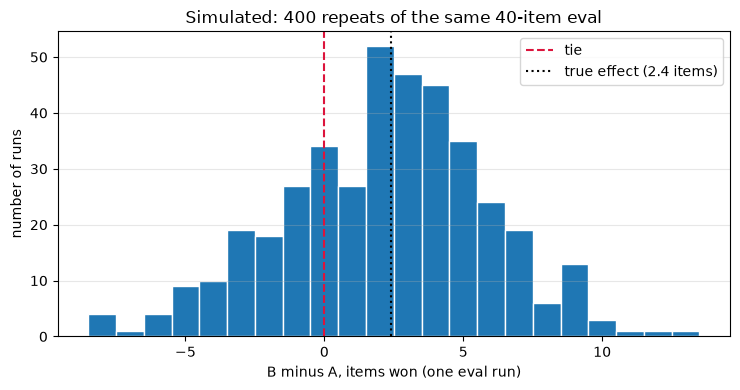

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(diffs, bins=range(min(diffs), max(diffs) + 2), align="left",
        edgecolor="white")
ax.axvline(0, color="crimson", linestyle="--", label="tie")
ax.axvline((TRUE_B - TRUE_A) * N_TASKS, color="black", linestyle=":",
           label=f"true effect ({(TRUE_B-TRUE_A)*N_TASKS:.1f} items)")
ax.set_xlabel("B minus A, items won (one eval run)")
ax.set_ylabel("number of runs")
ax.set_title(f"Simulated: {REPEATS} repeats of the same {N_TASKS}-item eval")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Paired beats unpaired, on identical data

The chapter's fourth recommendation: compare **question-level paired
differences**, not two summary statistics. Items differ in difficulty, and that
difficulty is shared by both models — so removing it removes noise.

In [7]:
N_PAIRED = 60
P_A, P_B = 0.70, 0.82        # a 12-point true difference
RHO = 0.70                   # how often the two models share an item's outcome draw

ITEM_DIFFICULTY = [random.Random(SEED + i).uniform(-0.20, 0.20)
                   for i in range(N_PAIRED)]

def draw_pair(rng):
    """Same items for both models, partially correlated outcomes.

    With probability RHO the two models see the same underlying draw for an
    item - they tend to fail the same hard items. Otherwise they draw
    independently. That correlation is what pairing exploits.
    """
    a, b = [], []
    for d in ITEM_DIFFICULTY:
        pa = min(max(P_A + d, 0.01), 0.99)
        pb = min(max(P_B + d, 0.01), 0.99)
        u = rng.random()
        a.append(1 if u < pa else 0)
        u2 = u if rng.random() < RHO else rng.random()
        b.append(1 if u2 < pb else 0)
    return a, b

def one_trial(seed):
    rng = random.Random(seed)
    a, b = draw_pair(rng)
    # unpaired: compare two proportions as if the items were unrelated
    pa, pb = sum(a) / N_PAIRED, sum(b) / N_PAIRED
    se_un = sqrt(pa * (1 - pa) / N_PAIRED + pb * (1 - pb) / N_PAIRED)
    z_un = (pb - pa) / se_un if se_un else 0.0
    # paired: per-item differences
    d = [bi - ai for ai, bi in zip(a, b)]
    md = statistics.fmean(d)
    sd = statistics.pstdev(d) or 1e-9
    z_pa = md / (sd / sqrt(N_PAIRED))
    return z_un, z_pa

TRIALS = 400
trials = [one_trial(SEED + 100 + i) for i in range(TRIALS)]
det_un = sum(1 for z, _ in trials if z > 1.96)
det_pa = sum(1 for _, z in trials if z > 1.96)

print(f"{N_PAIRED} items, true difference {P_B - P_A:+.0%}, "
      f"model correlation rho={RHO}")
print()
print(f"{'analysis':<26}{'detected the real difference':>30}")
print("-" * 58)
print(f"{'unpaired (two rates)':<26}{det_un:>12} / {TRIALS}  ({det_un/TRIALS:>6.1%})")
print(f"{'paired (per item)':<26}{det_pa:>12} / {TRIALS}  ({det_pa/TRIALS:>6.1%})")
print()
print("Same data, same models, same items. The difference is the analysis.")
print("Unpaired throws away the correlation that made the test sensitive.")

60 items, true difference +12%, model correlation rho=0.7

analysis                    detected the real difference
----------------------------------------------------------
unpaired (two rates)                93 / 400  ( 23.2%)
paired (per item)                  219 / 400  ( 54.8%)

Same data, same models, same items. The difference is the analysis.
Unpaired throws away the correlation that made the test sensitive.


## 4. Power: what would this eval need?

The chapter's fifth recommendation, and the one it says should change behaviour
this week.

In [8]:
def power_for(n_items, effect, base=0.70, trials=600, seed=SEED):
    rng = random.Random(seed)
    hits = 0
    for _ in range(trials):
        a = [1 if rng.random() < base else 0 for _ in range(n_items)]
        b = [1 if rng.random() < base + effect else 0 for _ in range(n_items)]
        pa, pb = sum(a) / n_items, sum(b) / n_items
        se_ = sqrt(pa * (1 - pa) / n_items + pb * (1 - pb) / n_items)
        if se_ and (pb - pa) / se_ > 1.96:
            hits += 1
    return hits / trials

sizes = [20, 40, 80, 150, 300, 600, 1200]
for effect in (0.05, 0.10):
    powers = [power_for(n, effect) for n in sizes]
    print(f"effect = {effect:+.0%} absolute")
    for n_, pw in zip(sizes, powers):
        bar = "#" * int(pw * 40)
        print(f"  n={n_:<6}power={pw:>5.0%}  {bar}")
    print()

effect = +5% absolute
  n=20    power=   8%  ###
  n=40    power=   7%  ##
  n=80    power=  11%  ####
  n=150   power=  14%  #####
  n=300   power=  26%  ##########
  n=600   power=  49%  ###################
  n=1200  power=  78%  ###############################



effect = +10% absolute
  n=20    power=  13%  #####
  n=40    power=  17%  ######
  n=80    power=  33%  #############
  n=150   power=  49%  ###################
  n=300   power=  80%  ################################
  n=600   power=  97%  ######################################
  n=1200  power= 100%  ########################################



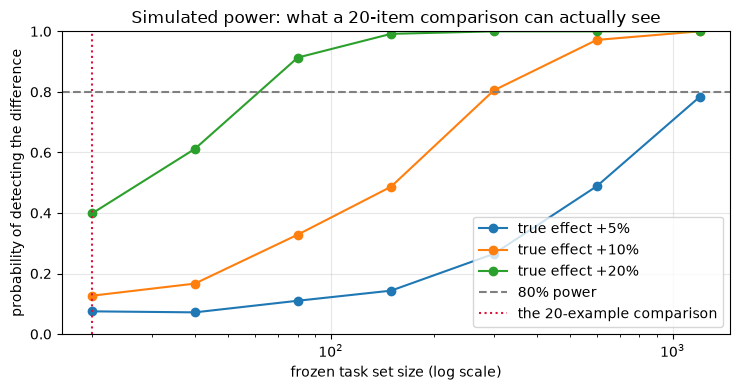

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for effect in (0.05, 0.10, 0.20):
    ax.plot(sizes, [power_for(n, effect) for n in sizes],
            marker="o", label=f"true effect {effect:+.0%}")
ax.axhline(0.8, linestyle="--", color="grey", label="80% power")
ax.axvline(20, linestyle=":", color="crimson", label="the 20-example comparison")
ax.set_xscale("log")
ax.set_xlabel("frozen task set size (log scale)")
ax.set_ylabel("probability of detecting the difference")
ax.set_ylim(0, 1)
ax.set_title("Simulated power: what a 20-item comparison can actually see")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

The chapter's sentence, now with a curve behind it:

> An enormous amount of confident model-selection folklore is built on evals
> that had no power to support it.

At twenty items, a five-point improvement is essentially undetectable. The
comparison will still *produce a winner* every time it is run — it simply will
not be the same winner.

Three practices follow, and none of them require a bigger model:

1. **Report n and a standard error, or report nothing.**
2. **Compare paired, per item.** It is free and it is the single largest
   sensitivity gain available here.
3. **Run the power analysis first.** If the eval cannot see the effect you
   intend to claim, the honest response is to stop claiming it — not to reach
   for a stronger model.

## Try it yourself

1. **Set `TRUE_A == TRUE_B`** and re-run section 2. Two identical models still
   produce a winner in almost every run. Look at how large the winning margins
   get.
2. **Cluster the items.** Make ten of the forty tasks come from one document
   with shared difficulty, then re-run the paired test. The chapter's second
   recommendation is clustered standard errors; watch why.
3. **Resample K times per item** (the chapter's third recommendation) and
   re-measure power. How much does K buy compared with more items?
4. **Find your own n.** Put in the effect you last claimed from an eval, and
   read off the task-set size it would have needed.